Данные взяты с ресурса https://www.kaggle.com/ "Влияние социальных сетей на психическое здоровье подростков(Social Media Impact on Teen Mental Health)"  https://www.kaggle.com/datasets/algozee/teenager-menthal-healy?resource=download

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [54]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [55]:
df.shape

(1200, 13)

In [56]:
# в dataset 1200 срок и 13 стобцов

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [58]:
# все строки заполнены, пропусков нет. тип данных соответствует названиям колонок

### Перевод столбцов
- age - возраст
- gender - пол
- daily_social_media_hours - ежедневные_социальные_медиа_часы
- platform_usage - использование платформы (какой соц. сетью пользуется)
- sleep_hours - часы сна
- screen_time_before_sleep - экранное время перед сном
- academic_performance - академическая успеваемость
- physical_activity - физическая активность
- social_interaction_level - уровень социального взаимодействия(высокий, низкий, средний)
- stress_level - уровень стресса
- anxiety_level - уровень тревожности
- addiction_level - уровень зависимости
- depression_label - метка депрессии

In [59]:
# Наличие дубликатов
num_duplicates = df.duplicated().sum()
print(f"\nКоличество полных дубликатов строк: {num_duplicates}")



Количество полных дубликатов строк: 0


### Анализ числовых переменных

In [60]:
# анализ числовых переменных сделаем через цикл
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    print(f"\nАнализ переменной: '{col}'")
    print(df[col].describe())


Анализ переменной: 'age'
count    1200.000000
mean       15.928333
std         2.021947
min        13.000000
25%        14.000000
50%        16.000000
75%        18.000000
max        19.000000
Name: age, dtype: float64

Анализ переменной: 'daily_social_media_hours'
count    1200.000000
mean        4.536667
std         2.029599
min         1.000000
25%         2.800000
50%         4.500000
75%         6.300000
max         8.000000
Name: daily_social_media_hours, dtype: float64

Анализ переменной: 'sleep_hours'
count    1200.000000
mean        6.449417
std         1.442677
min         4.000000
25%         5.200000
50%         6.500000
75%         7.600000
max         9.000000
Name: sleep_hours, dtype: float64

Анализ переменной: 'screen_time_before_sleep'
count    1200.000000
mean        1.740333
std         0.716660
min         0.500000
25%         1.100000
50%         1.800000
75%         2.400000
max         3.000000
Name: screen_time_before_sleep, dtype: float64

Анализ переменной: 

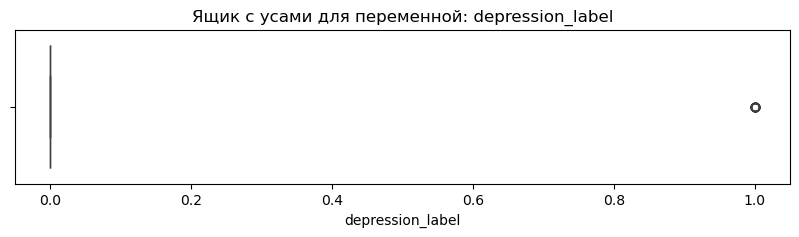

In [61]:
# Делать график распределения нет смысла, т.к все строки заполнены
# Сделаем график "ящик с усами" для выявления выбросов
plt.figure(figsize=(10, 2))
sns.boxplot(x=df[col])
plt.title(f'Ящик с усами для переменной: {col}')
plt.xlabel(col)
plt.show()

In [62]:
# единственная переменная где система определяет выброс, это 'depression_label', но нам известно, что там только 2 значения это 0 и 1.

# Исследование категориальных переменных

In [63]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f"\nАнализ переменной: '{col}'")
    counts = df[col].value_counts()
    print("Частотное распределение:")
    print(counts)
    print("\nОтносительное распределение:")
    print(df[col].value_counts(normalize=True) * 100)


Анализ переменной: 'gender'
Частотное распределение:
gender
male      615
female    585
Name: count, dtype: int64

Относительное распределение:
gender
male      51.25
female    48.75
Name: proportion, dtype: float64

Анализ переменной: 'platform_usage'
Частотное распределение:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Относительное распределение:
platform_usage
Instagram    34.250000
TikTok       33.166667
Both         32.583333
Name: proportion, dtype: float64

Анализ переменной: 'social_interaction_level'
Частотное распределение:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

Относительное распределение:
social_interaction_level
medium    34.666667
low       34.583333
high      30.750000
Name: proportion, dtype: float64


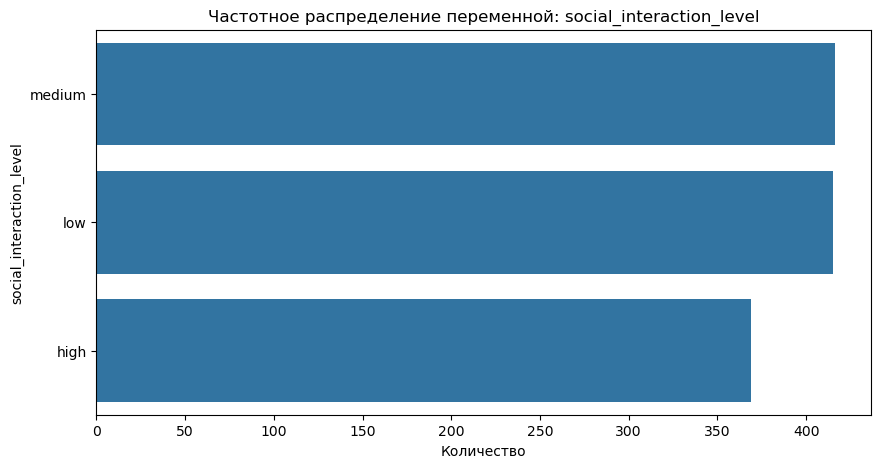

In [64]:
# График частотного распределения
plt.figure(figsize=(10, 5))
sns.countplot(y=df[col], order=counts.index) # y= для горизонтальных столбцов
plt.title(f'Частотное распределение переменной: {col}')
plt.xlabel('Количество')
plt.ylabel(col)
plt.show()


--- Анализ взаимосвязей ---


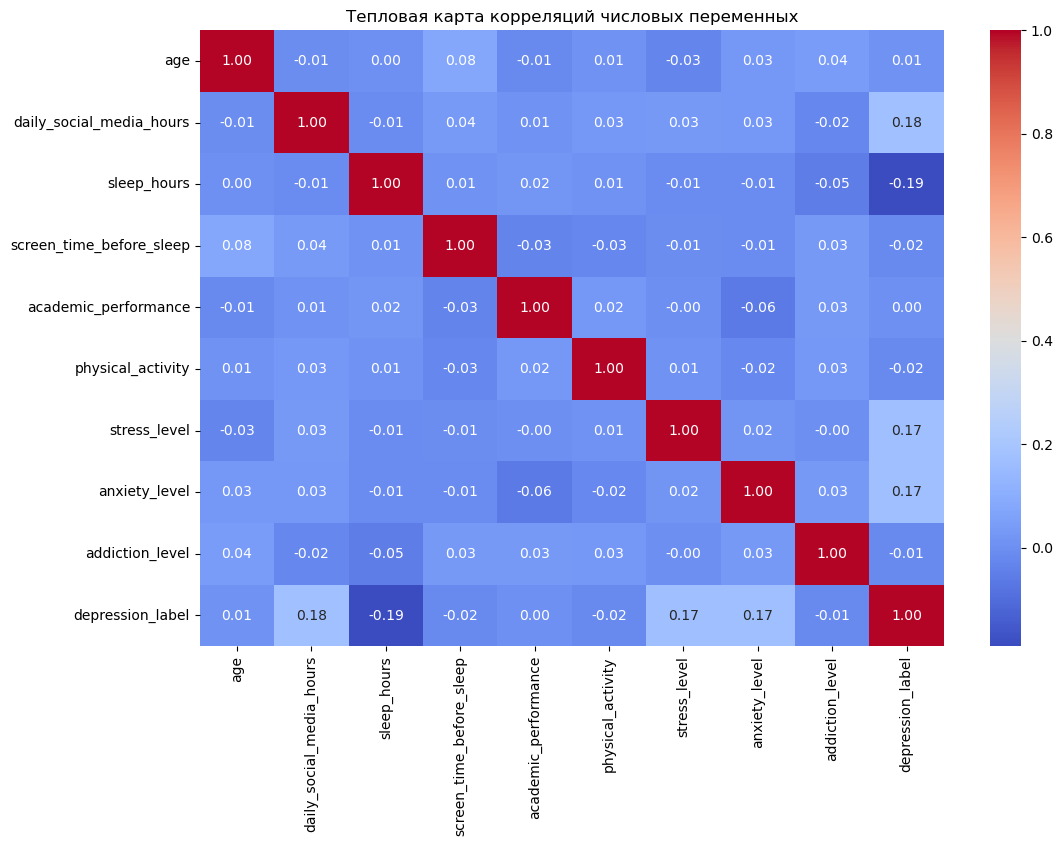

In [65]:
# --- Исследование взаимосвязей (пример: корреляции числовых переменных) ---
print("\n--- Анализ взаимосвязей ---")
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляций числовых переменных')
plt.show()


Анализ уровня стресса и пола: Средний 'Stress Level' по 'Gender'
gender
female    5.422222
male      5.468293
Name: stress_level, dtype: float64


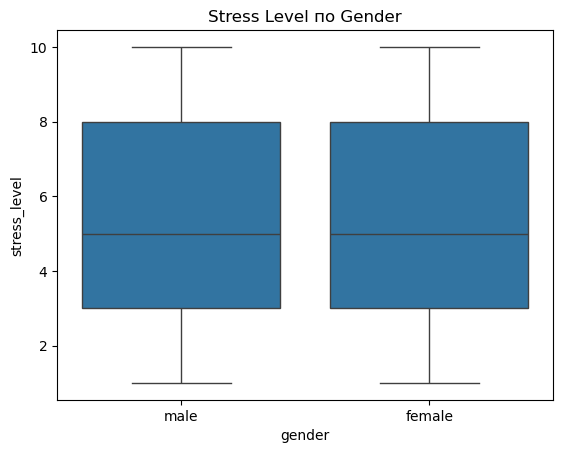

In [66]:
# Анализ взаимосвязи категориальных переменных с числовыми
print("\nАнализ уровня стресса и пола: Средний 'Stress Level' по 'Gender'")
print(df.groupby('gender')['stress_level'].mean())
sns.boxplot(x='gender', y='stress_level', data=df)
plt.title('Stress Level по Gender')
plt.show()

#### вывод: у мальчиков и девочек уровень стресса одинаковый

# Задаёмся вопросом кто больше пользуется соц. сетями

<Figure size 1200x700 with 0 Axes>

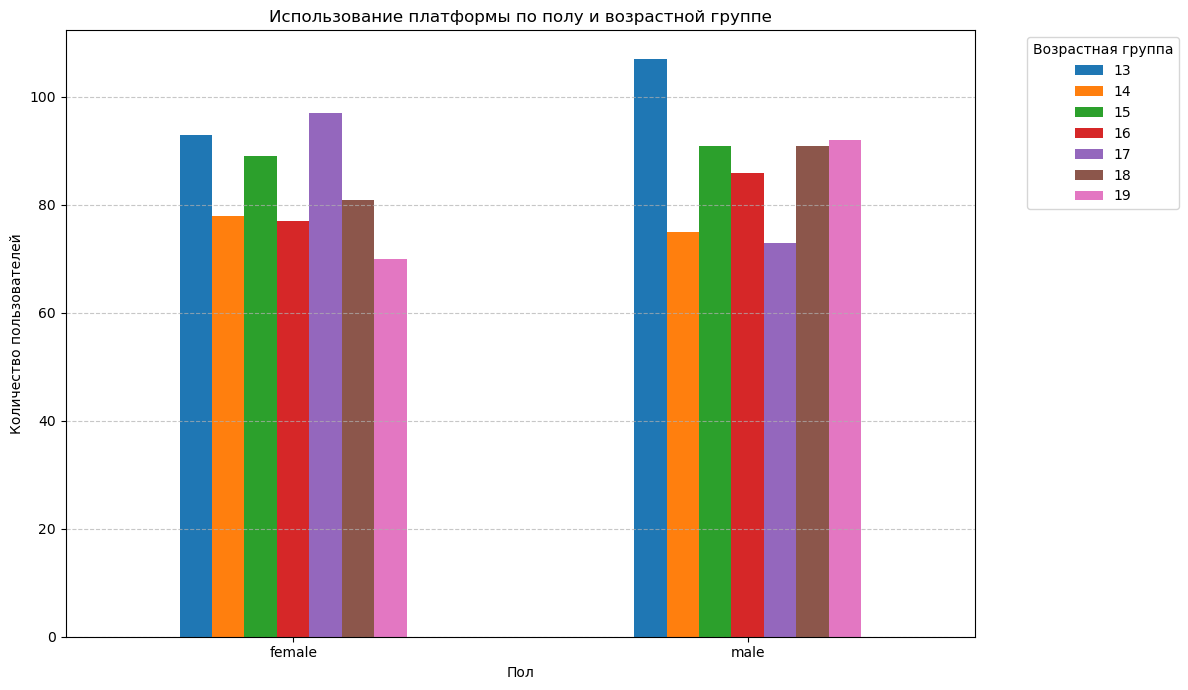

In [67]:
plt.figure(figsize=(12, 7))
usage_by_gender_age = df.groupby(['gender', 'age']).size().unstack(fill_value=0) # считаем все записи как пользователей платформы
usage_by_gender_age.plot(kind='bar', figsize=(12, 7))
plt.title('Использование платформы по полу и возрастной группе')
plt.xlabel('Пол')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=0) # Повернуть метки оси X, если необходимо
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Автоматически подгоняем параметры, чтобы они поместились в область графика
plt.show()

### как мы видим на графике, в целом парни больше пользуются соц. сетями, чем девушки(за явным исключением в 17 лет)

# Взаимосвязь экранного времени перед сном и уровнем тревожности

#### Корреляционный анализ

In [90]:
correlation = df['screen_time_before_sleep'].corr(df['anxiety_level'])
print(f"Коэффициент корреляции Пирсона между 'screen_time_before_sleep' и '{'anxiety_level'}': {correlation:.3f}")

Коэффициент корреляции Пирсона между 'screen_time_before_sleep' и 'anxiety_level': -0.010


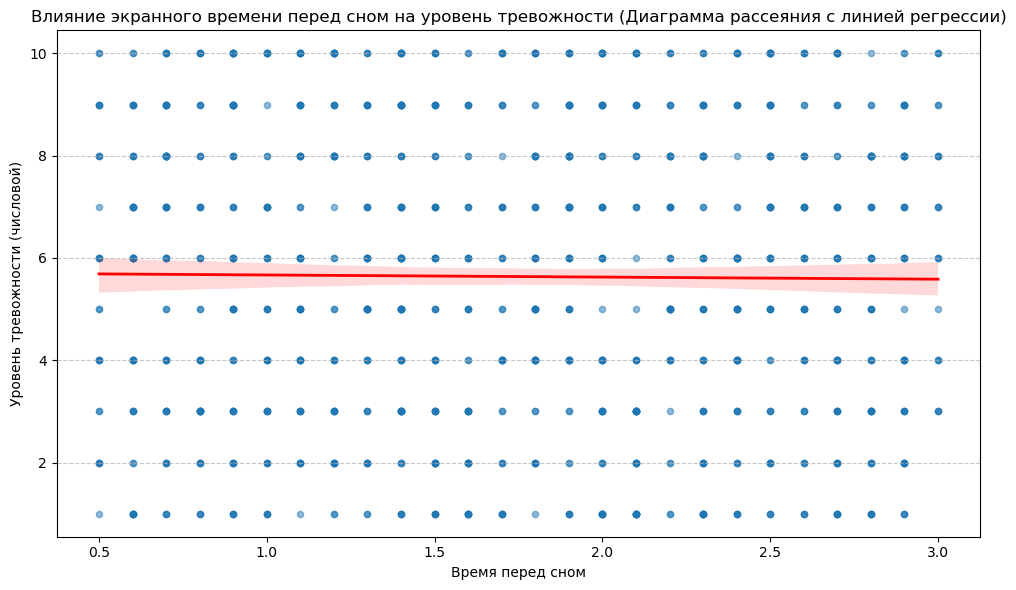

In [89]:
# График: Диаграмма рассеяния с линией регрессии
plt.figure(figsize=(10, 6))
sns.regplot(x='screen_time_before_sleep', y='anxiety_level', data=df,
            scatter_kws={'alpha':0.5, 's':20}, # Параметры точек
            line_kws={'color':'red', 'linewidth':2}) # Параметры линии регрессии

plt.title('Влияние экранного времени перед сном на уровень тревожности (Диаграмма рассеяния с линией регрессии)')
plt.xlabel('Время перед сном')
plt.ylabel('Уровень тревожности (числовой)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Регрессионный анализ

In [91]:
y = df['anxiety_level']
X = df['screen_time_before_sleep']
X = sm.add_constant(X) # Добавляем константу

model = sm.OLS(y, X).fit() # Создаем и обучаем модель

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          anxiety_level   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1282
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.720
Time:                        03:25:13   Log-Likelihood:                -2962.9
No. Observations:                1200   AIC:                             5930.
Df Residuals:                    1198   BIC:                             5940.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

### Анализ показал, что связи уровня тревожности и экранным временем перед сном, нет

# Рассмотрим связь ежедневные_социальные_медиа_часы и уровень социального взаимодействия

#### Корреляционный анализ

In [100]:
var1 = 'daily_social_media_hours'
var2 = 'social_interaction_level'

In [103]:
if df[var2].dtype == 'object':  # проводим преобразование категриального значения в числовое
    category_mapping = {'low': 0, 'medium': 1, 'high': 2}
    df[var2 + '_numeric'] = df[var2].map(category_mapping)
    var2_numeric = var2 + '_numeric'

In [105]:
correlation = df[var1].corr(df[var2_numeric])
print(f"Коэффициент корреляции Пирсона между '{var1}' и '{var2_numeric}': {correlation:.3f}")

Коэффициент корреляции Пирсона между 'daily_social_media_hours' и 'social_interaction_level_numeric': -0.016


#### Регрессионный анализ

In [106]:
y = df[var2_numeric]
X = df[var1]
X = sm.add_constant(X) # Добавляем константу для модели OLS
model = sm.OLS(y, X).fit() # Обучаем модель
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     social_interaction_level_numeric   R-squared:                       0.000
Model:                                          OLS   Adj. R-squared:                 -0.001
Method:                               Least Squares   F-statistic:                    0.2888
Date:                              Thu, 30 Apr 2026   Prob (F-statistic):              0.591
Time:                                      03:52:15   Log-Likelihood:                -1445.8
No. Observations:                              1200   AIC:                             2896.
Df Residuals:                                  1198   BIC:                             2906.
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                               coef    std err          t      P>|t|  

Text(0, 0.5, 'social_interaction_level_numeric')

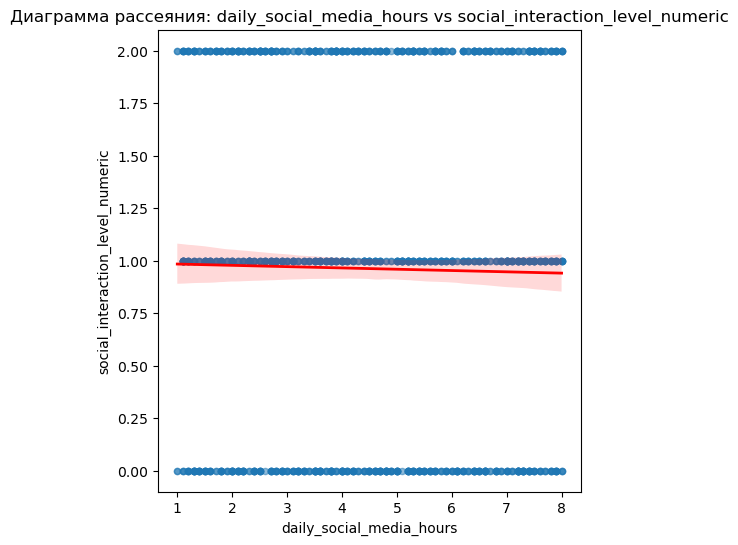

In [107]:
plt.figure(figsize=(12, 6))

# Диаграмма рассеяния с линией регрессии
plt.subplot(1, 2, 1) # Создаем подграфик 1
sns.regplot(x=var1, y=var2_numeric, data=df,
            scatter_kws={'alpha':0.5, 's':20},
            line_kws={'color':'red', 'linewidth':2})
plt.title(f"Диаграмма рассеяния: {var1} vs {var2_numeric}")
plt.xlabel(var1)
plt.ylabel(var2_numeric)

In [111]:
print(f"Корреляционный анализ показал коэффициент {correlation:.3f}. ")
if abs(correlation) < 0.1:
    print("Это указывает на очень слабую или отсутствующую линейную связь между ежедневным временем в социальных сетях и уровнем социального взаимодействия.")
elif correlation > 0:
    print("Присутствует слабая/умеренная/сильная положительная линейная связь: увеличение времени в соцсетях коррелирует с увеличением реального взаимодействия.")
else:
    print("Присутствует слабая/умеренная/сильная отрицательная линейная связь: увеличение времени в соцсетях коррелирует с уменьшением реального взаимодействия.")

print("\nРегрессионный анализ:")
print(f"*   R-squared ({model.rsquared:.3f}) показывает, что примерно {model.rsquared*100:.1f}% изменчивости уровня социального взаимодействия объясняется количеством часов в соцсетях.")
p_value = model.pvalues[var1]
print(f"*   P-значение для '{var1}' ({p_value:.3f}) {'ниже 0.05, что указывает на статистически значимое влияние' if p_value < 0.05 else 'выше 0.05, что указывает на статистически незначимое влияние'}.")
print(f"*   Коэффициент регрессии для '{var1}' ({model.params[var1]:.3f}) указывает, что при увеличении времени в соцсетях на 1 час, уровень социального взаимодействия ожидаемо изменяется на {model.params[var1]:.3f} (при условии значимости).")

Корреляционный анализ показал коэффициент -0.016. 
Это указывает на очень слабую или отсутствующую линейную связь между ежедневным временем в социальных сетях и уровнем социального взаимодействия.

Регрессионный анализ:
*   R-squared (0.000) показывает, что примерно 0.0% изменчивости уровня социального взаимодействия объясняется количеством часов в соцсетях.
*   P-значение для 'daily_social_media_hours' (0.591) выше 0.05, что указывает на статистически незначимое влияние.
*   Коэффициент регрессии для 'daily_social_media_hours' (-0.006) указывает, что при увеличении времени в соцсетях на 1 час, уровень социального взаимодействия ожидаемо изменяется на -0.006 (при условии значимости).


## таким образом, не смотря на общественное мнение, статистика говорит, что количество времени проводимое молодёжью в соц. сетях, не влияет на уровень социального взаимодействия.